In [1]:
# IMPORT STATEMENTS
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
import matplotlib.pyplot as plt
import bone
pd = bone.pd
np = bone.np
re = bone.re
hu = bone.hu

In [2]:
reload(mut)
reload(bone)
# import Datasets
# reload(Datasets)
import scipy
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [3]:
def getMastSpecificSig():
    mast_specific_sig = ['FCER1A', 'MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']
    wt1, l1 = [1], [mast_specific_sig]
    return wt1, l1

In [4]:
def getTCGA2017(self):
    self.prepareData("CRC80.2")
    atype = self.h.getSurvName('c Sex')
    atypes = ['female', 'male']
    ahash = {}
    self.initData(atype, atypes, ahash)
    return
bone.IBDAnalysis.getTCGA2017 = getTCGA2017

# mast specificity

def getAkoto2024Rhinovirus(self, tn=1):
    self.prepareData("M7", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['Mast']
    ahash = {}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getAkoto2024Rhinovirus = getAkoto2024Rhinovirus

def getDeGraaf2019Haemopedia(self, tn=1):
    self.prepareData("M28", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['Mast']
    ahash = {}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getDeGraaf2019Haemopedia = getDeGraaf2019Haemopedia


# Akoto 2024 Rhinovirus in LAD2 => M7

# de Graaf 2019 Haemopedia with Mast Cells = > M28


In [ ]:
# (3a)

In [5]:
def plotPair(dbid, id1, id2, n1=None, n2=None):
    ana = bone.IBDAnalysis()
    ana.getSurvival(dbid)
    fileName = ana.source+" "+ana.name
    w,h = (6.4, 4.8)
    dpi = 100
    fig = bone.plt.figure(figsize=(w,h))
    ax = fig.add_axes([70.0/w/dpi, 54.0/h/dpi, 1-2*70.0/w/dpi, 1-2*54.0/h/dpi])
    df = pd.DataFrame()
    id1 = list(ana.h.getIDs(id1))[0]
    id2 = list(ana.h.getIDs(id2))[0]
    if n1 is None:
        n1 = ana.h.getSimpleName(id1)
    if n2 is None:
        n2 = ana.h.getSimpleName(id2)
    df[id1] = pd.to_numeric(ana.h.getExprData(id1)[2:])
    df[id2] = pd.to_numeric(ana.h.getExprData(id2)[2:])
    df['color'] = 'darkblue'
    ax = df.dropna().plot.scatter(id1, id2, c="color", s=20, alpha=0.5,
                    rasterized=True, title=ana.getTitle(), ax=ax)
    thrx = ana.h.getThrData(id1)
    thry = ana.h.getThrData(id2)
    ax.axhline(y=float(thry[0]), color='tomato')
    ax.axhline(y=float(thry[2]), color='cyan')
    ax.axhline(y=float(thry[3]), color='cyan')
    ax.axvline(x=float(thrx[0]), color='tomato')
    ax.axvline(x=float(thrx[2]), color='cyan')
    ax.axvline(x=float(thrx[3]), color='cyan')
    ax.set_xlabel(n1)
    ax.set_ylabel(n2)
    return ax, fileName

GTEx_V8_genes_tpm (n = 17382)
GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2
0 [0, 0] GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2 GL52.2
GTEx GTEx_V8_genes_tpm
GTEx_V8_genes_tpm (n = 17382)
GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2
0 [0, 0] GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2 GL52.2
GTEx GTEx_V8_genes_tpm
GTEx_V8_genes_tpm (n = 17382)
GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2
0 [0, 0] GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2 GL52.2
GTEx GTEx_V8_genes_tpm
GTEx_V8_genes_tpm (n = 17382)
GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2
0 [0, 0] GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2 GL52.2
GTEx GTEx_V8_genes_tpm
GTEx_V8_genes_tpm (n = 17382)
GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2
0 [0, 0] GTEx http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL52.2 GL52.

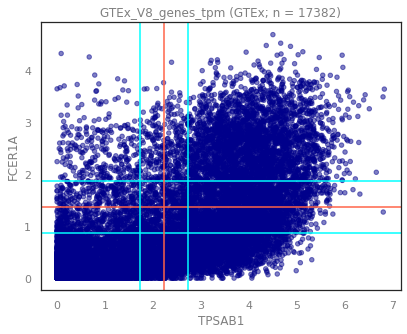

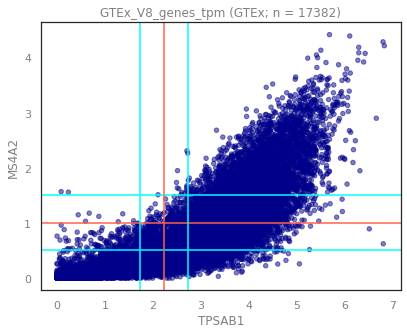

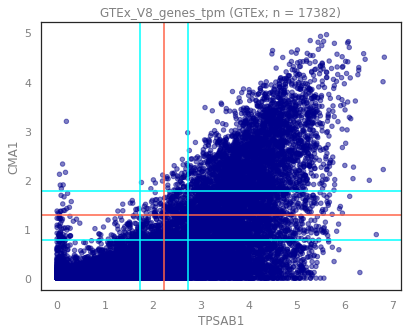

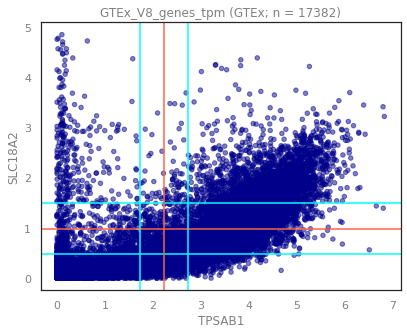

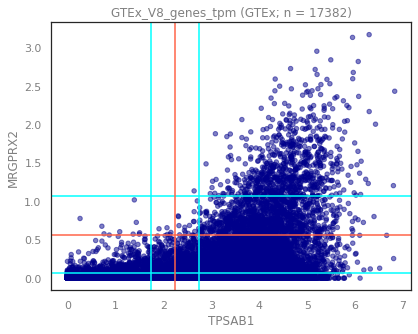

In [9]:
ax, pdfName = plotPair("GL52.2", 'TPSAB1','FCER1A')
print(pdfName)
fig = ax.figure              
fig.savefig(f"pdf-res/3A-FCER1A-{pdfName}.pdf", dpi=100, transparent=True, bbox_inches='tight')
    
ax, pdfName = plotPair("GL52.2", 'TPSAB1','MS4A2')
print(pdfName)
fig = ax.figure              
fig.savefig(f"pdf-res/3B-MS4A2-{pdfName}.pdf", dpi=100, transparent=True, bbox_inches='tight')

ax, pdfName = plotPair("GL52.2", 'TPSAB1','CMA1')
print(pdfName)
fig = ax.figure              
fig.savefig(f"pdf-res/3C-CMA1-{pdfName}.pdf", dpi=100, transparent=True, bbox_inches='tight')

ax, pdfName = plotPair("GL52.2", 'TPSAB1','SLC18A2')
print(pdfName)
fig = ax.figure              
fig.savefig(f"pdf-res/3D-SLC18A2-{pdfName}.pdf", dpi=100, transparent=True, bbox_inches='tight')

ax, pdfName = plotPair("GL52.2", 'TPSAB1','MRGPRX2')
print(pdfName)
fig = ax.figure              
fig.savefig(f"pdf-res/3E-MRGPRX2-{pdfName}.pdf", dpi=100, transparent=True, bbox_inches='tight')


In [ ]:
#(3b)

In [7]:
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload
except NameError:
    try:
        from importlib import reload
    except ImportError:
        from imp import reload

import SMaRT.MacUtils as mut
reload(mut)

import bone
reload(bone)
#import Datasets
#reload(Datasets)
pd = bone.pd
np = bone.np
re = bone.re
hu = bone.hu

import os
import requests
os.environ['HTTP_PROXY'] = os.environ['http_proxy'] = 'http://localhost:5000/'
os.environ['HTTPS_PROXY'] = os.environ['https_proxy'] = 'http://localhost:5000/'
os.environ['NO_PROXY'] = os.environ['no_proxy'] = '127.0.0.1,localhost,.local'

/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


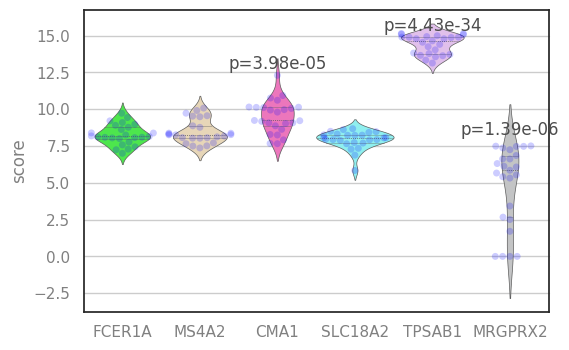

In [8]:
wt1, l1 = [1], [['FCER1A','MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']]
ana = bone.IBDAnalysis()
ana.prepareData("M3", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3F-GSE330761 Dwyer 2026 Mast Cells CD25 (n = 25).pdf"),
                   bbox_inches='tight')

/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 38.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


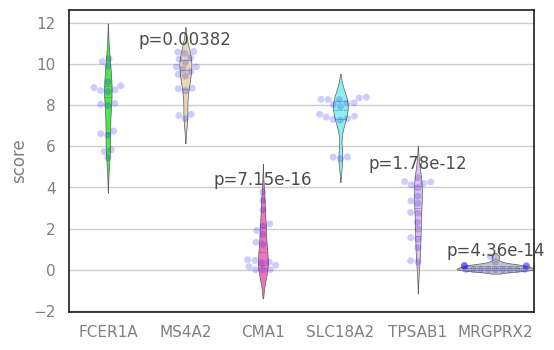

In [10]:
wt1, l1 = [1], [['FCER1A','MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']]
ana = bone.IBDAnalysis()
ana.prepareData("M42", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3G-GSE222701 Miyake 2023 Stimulated Pre vs Mature Basophils (n = 18).pdf"),
                   bbox_inches='tight')

/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


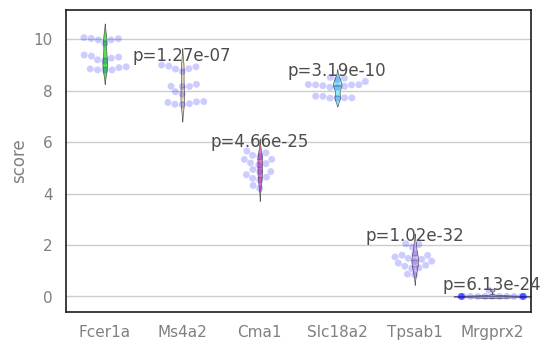

In [11]:
wt1, l1 = [1], [['Fcer1a','Ms4a2', 'Cma1', 'Slc18a2', 'Tpsab1', 'Mrgprx2']]
ana = bone.IBDAnalysis()
ana.prepareData("M33", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3H-GSE272532 Ito 2024 Mouse Basophils (n = 18).pdf"),
                   bbox_inches='tight')

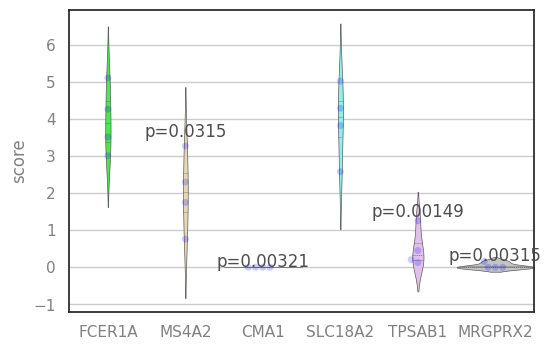

In [12]:
wt1, l1 = [1], [['FCER1A','MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']]
ana = bone.IBDAnalysis()
ana.prepareData("M34", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3I-GSE281339 Gorenjak 2026 Human Asthma Basophils (n = 4).pdf"),
                   bbox_inches='tight')

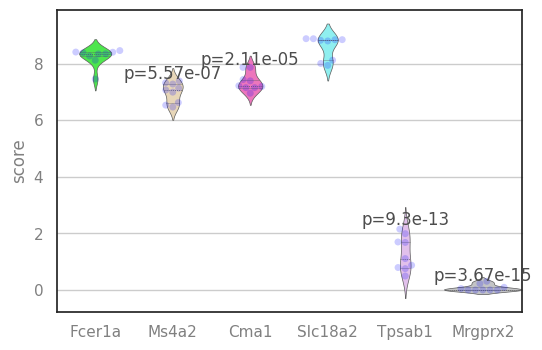

In [13]:
wt1, l1 = [1], [['Fcer1a','Ms4a2', 'Cma1', 'Slc18a2', 'Tpsab1', 'Mrgprx2']]
ana = bone.IBDAnalysis()
ana.prepareData("M36", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3J-GSE234541 Takahashi 2023 Bone Marrow Basophils (n = 9).pdf"),
                   bbox_inches='tight')

In [ ]:
wt1, l1 = [1], [['Fcer1a','Ms4a2', 'Cma1', 'Slc18a2', 'Tpsab1', 'Mrgprx2']]
ana = bone.IBDAnalysis()
ana.prepareData("M41", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3K-GSE206593 Miyake 2023 Stimulated Basophils (n = 6).pdf"),
                   bbox_inches='tight')

In [ ]:
#(3c)

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DISCOVERY_GENES = ['FCER1A', 'MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']

DISCOVERY_COLORS = {
    'FCER1A':'#C8873B','Fcer1a': '#C8873B',
    'MS4A2':   '#C8873B', 'Ms4a2':   '#C8873B',
    'CMA1': '#C8873B', 'Cma1': '#C8873B',
    'SLC18A2':'#C8873B', 'Slc18a2':'#C8873B',
    'TPSAB1': '#C8873B', 'Tpsab1': '#C8873B',   
     'MRGPRX2':'#2C6E8F',  'Mrgprx2':'#2C6E8F'}

def _colors_for(genes, palette=None):
    palette = palette or DISCOVERY_COLORS
    fallback, out, k = plt.cm.tab10.colors, [], 0
    for g in genes:
        if g in palette:
            out.append(palette[g])
        else:                                   
            out.append(fallback[k % len(fallback)]); k += 1
    return out

# cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
def load_celltype(ana, dataset_id, celltype_field="c cell type_ch1",
                  atypes=('Mast',), ahash=None,
                  cfile=None):
    if cfile is None:
        ana.prepareData(dataset_id)
    else:
        ana.prepareData(dataset_id, cfile=cfile)
#     ana.prepareData(dataset_id, cfile=cfile)
    atype = ana.h.getSurvName(celltype_field)
    ana.initData(atype, list(atypes), ahash or {})
    return ana

def load_celltype_general(ana, dataset_id, celltype_field="c cell type_ch1",
                  atypes=('Mast',), ahash=None):
    ana.prepareData(dataset_id)
    atype = ana.h.getSurvName(celltype_field)
    ana.initData(atype, list(atypes), ahash or {})
    return ana

def plot_marker_distribution(ana, source_org="hm", genes=DISCOVERY_GENES, name="dataset", *,
                             ylabel="Gene Expression",
                             order_by="input",          # "median" | "input"
                             palette=None, ax=None,
                             save=False, savedir="pdf-res"):
    
    if source_org=="hm":
        pass
    else:
        genes = ['Fcer1a','Ms4a2','Cma1','Slc18a2','Tpsab1','Mrgprx2']
        print("mus musculus")


    expr, dropped = {}, []
    for g in genes:
        e = ana.h.getExprData(g)
        if e is None or len(e) < 3:
            dropped.append(g); continue
        v = pd.to_numeric(pd.Series(e[2:]), errors="coerce").dropna().values
        if len(v) == 0:
            dropped.append(g); continue
        expr[g] = v
    if dropped:
        print(f"[WARN] {name}: not found -> {', '.join(dropped)}")
    if not expr:
        raise ValueError(f"{name}: none of the requested genes were found")

    if order_by == "median":
        order = sorted(expr, key=lambda g: np.median(expr[g]), reverse=True)
    else:                                        # keep input order -> aligns panels
        order = [g for g in genes if g in expr]

    data = [expr[g] for g in order]
    cols = _colors_for(order, palette)
    n    = max(len(v) for v in data)

    own_fig = ax is None
    fig, ax = (plt.subplots(figsize=(1.05 * len(order) + 1.2, 4.3))
               if own_fig else (ax.figure, ax))

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="#E9E9E9", linewidth=0.8)
    vp = ax.violinplot(data, positions=range(len(data)), widths=0.7, showmedians=True, showextrema=False)
    for body, c in zip(vp["bodies"], cols):
        body.set_facecolor(c); body.set_alpha(0.25); body.set_edgecolor(c)
        body.set_linewidth(1.0)
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(1.6)

    rng = np.random.default_rng(0)               # jittered raw points = n
    for i, (vals, c) in enumerate(zip(data, cols)):
        ax.scatter(rng.normal(i, 0.06, len(vals)), vals,
                   s=18, color=c, edgecolor="white", linewidth=0.4, zorder=3)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, style="italic")
    ax.set_ylabel(ylabel)
    ax.set_title(name, fontsize=11)
#     ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3)
    ax.margins(x=0.04)
    ax.text(0.99, 1.02, f"n = {n}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="#777")
    
    savedir = "pdf-res"

    if own_fig:
        fig.tight_layout()
    if save:
        os.makedirs(savedir, exist_ok=True)
        fig.savefig(f"{savedir}/Fig3c-{name}.pdf", bbox_inches="tight", transparent=True)
    return fig, ax, {g: expr[g] for g in order}

Genentech Cell-line RNASeq (n = 675)
EGA http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL9
0 [0] EGA http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL9 GL9


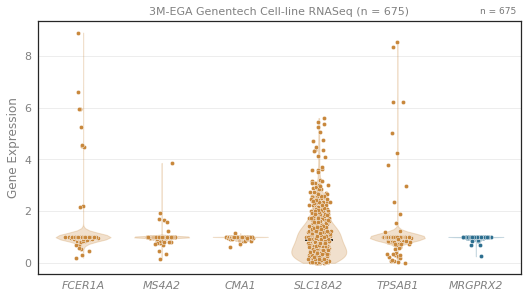

HPA 109 immune cell samples RNASeq (n = 109)
HPA http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL20.3
0 [0] HPA http://hegemon.ucsd.edu/Tools/explore.php?key=global&id=GL20.3 GL20.3


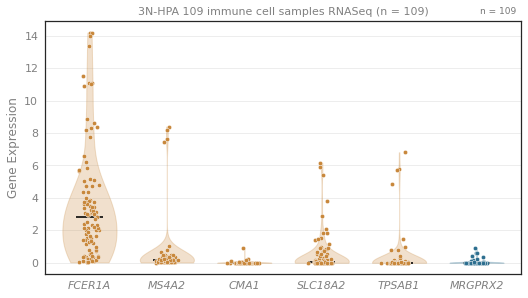

de Graaf 2019 Haemopedia with Mast Cells (n = 203)
GSE77098 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M28
0 [0] GSE77098 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M28 M28


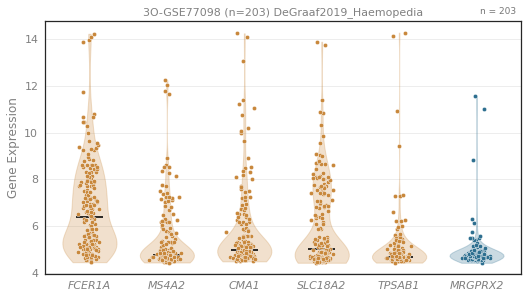

ImmGen Project (n = 678)
GSE15907 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=G18
0 [0] GSE15907 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=G18 G18
mus musculus


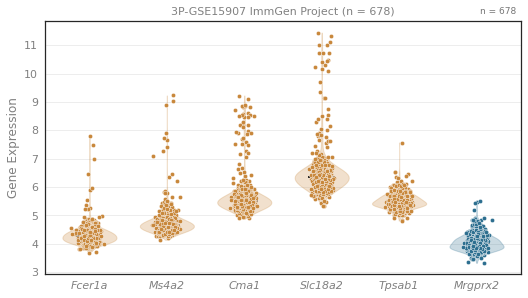

In [16]:
ana = bone.IBDAnalysis()
pk ="/Users/prisha.kaushik/public_html/Hegemon/explore.conf"

##############   Non-mast cell lines
# Genentech → EGA  (3a4)
load_celltype(ana, "GL9", "c Cell_line", atypes=[""])
plot_marker_distribution(ana, name="3M-EGA Genentech Cell-line RNASeq (n = 675)", save=True)
plt.show()

############### Immune cells
# HPA  → Global (109 samples) (3a5b)
load_celltype(ana, "GL20.3", "c Tissue", atypes=[""])
plot_marker_distribution(ana, name="3N-HPA 109 immune cell samples RNASeq (n = 109)", save=True)
plt.show()

# Haemopedia (w/ mast) → GSE77098, M28 (3a5a)
load_celltype(ana, "M28", "c cell type_ch1", cfile=pk, atypes=[""])
plot_marker_distribution(ana, name="3O-GSE77098 (n=203) DeGraaf2019_Haemopedia", save=True)
plt.show()

#############################  Blood
# Blood → GSE15907, Blood (ImmGen)  (3a3)
load_celltype(ana, "G18", "c Cell Type", atypes=[""])
plot_marker_distribution(ana, source_org="mm", name="3P-GSE15907 ImmGen Project (n = 678)", save=True)
plt.show()

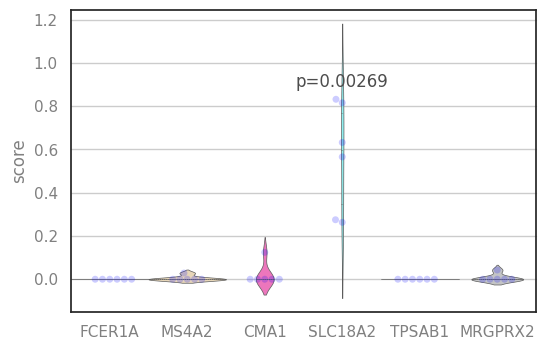

In [17]:
wt1, l1 = [1], [['FCER1A','MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']]
ana = bone.IBDAnalysis()
ana.prepareData("M48", "/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
lval = [ pd.to_numeric(ana.h.getExprData(k)[2:]) for k in l1[0]]
atypes = l1[0]
ax = bone.plotViolin(lval, atypes, {'vert':1, 'w':6, 'h':4})

# Save to pdf-res folder
outdir = "pdf-res"
os.makedirs(outdir, exist_ok=True)
ax.figure.savefig(os.path.join(outdir, "3Q-GSE320506 Shao 2026 HaCaT Keratinocytes (n = 6).pdf"),
                   bbox_inches='tight')